# Glacier surface wave velocity anisotropy inversion practical

Skience 2026

In [1]:
# Import neccessary modules:
import numpy as np
import matplotlib.pyplot as plt
import os, sys 
import pyproj
import pandas as pd
import glob
import NonLinLocPy
import matplotlib
import obspy 
from numba import jit
# from cmcrameri import cm as cmc
%reload_ext autoreload
%matplotlib inline

# And import in some custom functions:
from useful_functions import *



## 0. The data and the problem

### Data:

The dataset used here is a DAS dataset collected at Gornergletscher in October 2023. It consists of 600 m of fibreoptic cable sampling strain at every 1.6 m. The fibre was deployed in a 100 x 100 m grid over a crevasse field.

### The workshop problem:

The aim here is to use this dataset to study anisotropy caused by the crevasse field. Specifically, we will attempt to measure how surface wave velocities vary azimuthally. To do this, we will:
1. Load in the source (icequakes) and receiver (fibreoptic channels) geometry and perform some initial quality control.
2. We will then use the source-receiver geometry to set up a simple synthetic inversion case. This will involve generating analytical surface wave travel times between pairs of receivers for the real source-receiver geometry. 
3. These synthetic data will then be used to test the ability of the experiment geometry to resolve any anisotropy, performing a receiver-receiver travel-time inversion and compare the results to the synthetic model.
4. We will then move on to looking at the real data. This will include preprocessing to calculate the travel times between pairs of receivers (via cross-correlation). [Note: This step is time consuming, so the cross-correlations are pre-generated. But code is provided to regenerate these if desired].
5. The real data will then be used to perform a single inversion for any anisotropic velocity structure. 
6. However, the problem is actually more complex. When one updates the velocity structure, the icequake source locations also vary, which effects the receiver-receiver travel times. The problem is therefore non-linear. Here, we also develop a simple location inversion algorith. We then iteratively invert for velocity structure and locations, updating the solutions until we converge upon a solution.
7. You can then explore the effect of varying the parameters + data preprocessing steps and the effect on the inversion. Especially focus on what key challenges might be and what the limitations of the data are.
8. Finally, you may want to think about how to develop/explore this problem further. You may want to think about how to extract more information from the data, quantify uncertainty, or study other properties of the glacier system.


### Skills learnt/experience gained:
- Exposure to fibreoptic sensing data
- Introduction to linear inversion (and a very simple approach to non-linear systems)
- Introduction to glacier anisotropy


## 1. Load in source and receiver geometry:

In [2]:
# Load in receiver geometry:
receivers_fname = os.path.join("input_data", "gornerglethscer_das_and_nodes_qm_stations_POOR_COUPLED_CH_REMOVED.csv") 

# Import receivers and convert to cartesian coordinates:
gproj = pyproj.Proj(proj="lcc", units="km", lon_0=7.817, lat_0=45.9793, lat_1=45.979,
             lat_2=45.9796, datum="WGS84", ellps="WGS84", no_defs=True)
cproj = pyproj.Proj(proj="longlat", datum="WGS84", ellps="WGS84", no_defs=True)
latlon_to_km_conv = pyproj.Transformer.from_proj(cproj, gproj)
receivers_df = pd.read_csv(receivers_fname)
x_km, y_km = latlon_to_km_conv.transform(receivers_df['Longitude'].values, receivers_df['Latitude'].values)
receivers_df['x_m'] = x_km #/ 1000
receivers_df['y_m'] = y_km #/ 1000
receivers_df['z_m'] = 0.

# And remove nodes:
receivers_df = receivers_df[~receivers_df.Name.str.contains("N")] # Remove nodes
receivers_df.reset_index(drop=True, inplace=True)

# Remove channels on bends:
recs = receivers_df['Name'].values
remove_receivers_on_bends = True
# Remove channels on bends:
if remove_receivers_on_bends:
    bend_angle_filt_deg = 30
    count=0
    prev_rec = None
    for rec in recs:
        # Sort current iter:
        rec_row = receivers_df.loc[receivers_df['Name'] == rec]
        if count>1:
            curr_vec = np.array([rec_row['x_m'], rec_row['y_m'], rec_row['z_m']]).reshape(3)        
            vec1 = curr_vec - prev_vec
            vec2 = prev_vec - prev_prev_vec
            theta_das = np.arccos(np.dot(vec1, vec2) / ( np.linalg.norm(vec1) * np.linalg.norm(vec2) ))
            # Remove if exceeds certain angle:
            if np.rad2deg(theta_das) > bend_angle_filt_deg:
                curr_rec_idx = np.where(recs==rec)[0][0]
                receivers_df.drop(receivers_df.loc[receivers_df['Name']==rec].index, inplace=True)
        # And setup for next iter:
        if count == 0:
            prev_prev_vec = np.array([rec_row['x_m'], rec_row['y_m'], rec_row['z_m']]).reshape(3)
        else:
            prev_prev_vec = prev_vec.copy()
        prev_vec = np.array([rec_row['x_m'], rec_row['y_m'], rec_row['z_m']]).reshape(3)
        count+=1


/var/folders/hg/xp5sp5p14knc98zsdqx2p7cw0000gn/T/ipykernel_17275/815054919.py:34: RuntimeWarning: invalid value encountered in arccos
  theta_das = np.arccos(np.dot(vec1, vec2) / ( np.linalg.norm(vec1) * np.linalg.norm(vec2) ))


In [3]:
# Load in source geometry:
# Read in event info:
nlloc_hyp_filenames = glob.glob(os.path.join("input_data", "loc.Tom__RunNLLoc000.*.*.grid0.loc.hyp"))
nlloc_hyp_filenames.sort()

# Specify event datastore:
sources_df = pd.DataFrame({'event_uid': [], 'x_m': [], 'y_m': [], 'z_m': []})

# Loop through events:
for event_idx in range(len(nlloc_hyp_filenames)):
    # Read in nlloc event data:
    nlloc_hyp_data = NonLinLocPy.read_nonlinloc.read_hyp_file(nlloc_hyp_filenames[event_idx])
    event_uid = str(nlloc_hyp_data.origin_time).replace('-','').replace(':','').replace('T','').replace('Z','')

    # Convert source to cartesian coordinates:
    src_lonlat = [nlloc_hyp_data.max_prob_hypocenter['lon'], nlloc_hyp_data.max_prob_hypocenter['lat']]
    z_km_src = -10.0  # Source at 10 metres from surface (as positive up)
    x_km_src, y_km_src = latlon_to_km_conv.transform(src_lonlat[0], src_lonlat[1])
    xyz_src_m = np.array([x_km_src, y_km_src, z_km_src]) 

    # And append event to dataframe:
    df_tmp = pd.DataFrame({'event_uid': [event_uid], 'x_m': [x_km_src], 'y_m': [y_km_src], 'z_m': [z_km_src]})
    sources_df = pd.concat([sources_df, df_tmp], ignore_index=True)

display(sources_df)


,event_uid,x_m,y_m,z_m
0,20231022051555.711278,-0.000310,-0.028566,-10.0
1,20231022053113.701369,-0.055717,-0.011004,-10.0
2,20231022053231.529253,-0.069355,0.014450,-10.0
3,20231022061913.009365,0.005579,-0.018340,-10.0
4,20231022062604.243022,0.012321,-0.048684,-10.0
5,20231022063844.215460,-0.073695,0.024342,-10.0
6,20231022064908.752050,-0.064396,0.011893,-10.0
7,20231022071634.816644,-0.026657,0.005780,-10.0
8,20231022074050.624021,-0.016118,0.054019,-10.0
9,20231022075529.629635,0.003100,0.027454,-10.0


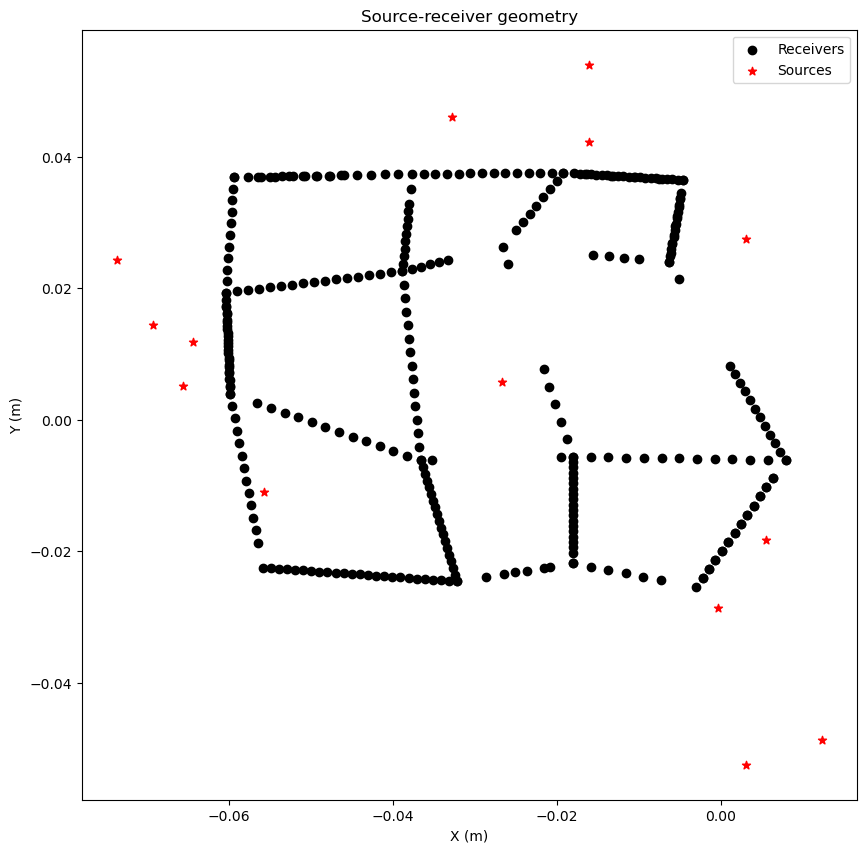

In [4]:
# And plot initial sources and receivers geometry:
plt.figure(figsize=(10, 10))
plt.scatter(receivers_df['x_m'], receivers_df['y_m'], marker='o', color='k', label='Receivers')
plt.scatter(sources_df['x_m'], sources_df['y_m'], marker='*', color='r', label='Sources')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Source-receiver geometry')
plt.legend()
plt.show()

In [5]:
# Set some constraints with channel distances and orientations to correlate:
min_rec_dist_km = 0.01 # (no point correlating channels that are too close together as they will be very similar and not give much additional info)
max_orientation_diff_deg = 45.0 # (no point correlating channels that are too far apart in orientation as they will not be similar)

# Calculate receiver orientations relative to north:
north_vec = np.array([0,1,0])
receivers_df['azimuth_deg'] = pd.Series(np.zeros(len(receivers_df)), index=receivers_df.index) #
# Loop through receivers and calculate azimuth of each DAS channel:
for i in range(len(receivers_df)):
    if i==0:
        # For the first receiver, set the reference channel to be the first channel:
        xyz_das_pref_channel_ref = np.array([receivers_df['x_m'].values[i], receivers_df['y_m'].values[i], receivers_df['z_m'].values[i]])
    else:
        # For the other receivers, calculate the azimuth of the receiver relative to the reference channel:
        das_vec = np.array([receivers_df['x_m'].values[i], receivers_df['y_m'].values[i], receivers_df['z_m'].values[i]]) - xyz_das_pref_channel_ref
        # Calculate the azimuth of the DAS channel relative to north:
        theta_das_deg = np.rad2deg(np.arccos(np.dot(north_vec, das_vec) / ( np.linalg.norm(north_vec) * np.linalg.norm(das_vec) )))
        if theta_das_deg < 0:
            theta_das_deg += 360.0
        elif theta_das_deg > 360.0:
            theta_das_deg -= 360.0
        receivers_df['azimuth_deg'].iloc[i] = theta_das_deg
        if i == 1:
            receivers_df['azimuth_deg'].iloc[0] = theta_das_deg
        # And set next reference channel:
        xyz_das_pref_channel_ref = np.array([receivers_df['x_m'].values[i], receivers_df['y_m'].values[i], receivers_df['z_m'].values[i]])

# And find receiver pairs that follow the constraints:
receiver_corr_pairs = np.zeros((0,2), dtype=int)
for i in range(len(receivers_df)):
    for j in range(i+1, len(receivers_df)):
        # Calculate distance between receivers:
        rec_dist_km = np.sqrt((receivers_df['x_m'].values[i] - receivers_df['x_m'].values[j])**2 + (receivers_df['y_m'].values[i] - receivers_df['y_m'].values[j])**2)
        # Calculate orientation difference:
        rec_orientation_diff_deg = np.abs(receivers_df['azimuth_deg'].values[i] - receivers_df['azimuth_deg'].values[j])

        # And deal with if orientation difference is because of fibre in the opposite direction:
        if rec_orientation_diff_deg > 90.:
            rec_orientation_diff_deg = 180 - rec_orientation_diff_deg

        # # If the distance is greater than the minimum distance and the orientation difference is less than the maximum orientation difference, add to list of pairs:
        if rec_dist_km > min_rec_dist_km and rec_orientation_diff_deg < max_orientation_diff_deg:
            receiver_corr_pairs = np.vstack((receiver_corr_pairs, [i,j]))








/var/folders/hg/xp5sp5p14knc98zsdqx2p7cw0000gn/T/ipykernel_17275/3016542532.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  receivers_df['azimuth_deg'].iloc[i] = theta_das_deg
/var/folders/hg/xp5sp5p14knc98zsdqx2p7cw0000gn/T/ipykernel_1

## 2. Setup synthetic test case:

In [6]:
# Setup synthetic test case:

# Create function to generate synthetic data (with noise):
def generate_synthetic_data(receivers_df, sources_df, model, receiver_corr_pairs, noise_level=0.01):
    """
    Generate synthetic differential arrival times for the given receivers with added noise.

    Parameters:
    receivers_df (pd.DataFrame): DataFrame containing receiver coordinates and names.
    sources_df (pd.DataFrame): DataFrame containing source coordinates.
    model (np.array): Model parameters [vfast, vslow, fast_dir].
    receiver_corr_pairs (np.array): Array of receiver pairs to correlate.
                                    (Each row is a pair of receiver indices.)
    noise_level (float): Standard deviation of the Gaussian noise to be added.

    Returns:
    """

    # Generate synthetic differential arrival times:
    num_srcs = len(sources_df)
    synthetic_data = np.zeros((num_srcs, receiver_corr_pairs.shape[0]))

    for i in range(num_srcs):
        # for j in range(num_receivers):
        #     for k in range(i + 1, num_receivers):
                # # Only process if the source and receivers are not the same and top diagonal:
                # if j != k and j < k:
        # And only process if the receiver pair is in the specifified correlation pairs:
        for ii in np.arange(len(receiver_corr_pairs)):
            j = int(receiver_corr_pairs[ii,0])
            k = int(receiver_corr_pairs[ii,1])
            # Calculate the distance between the source and the receivers:
            dist_ij = np.sqrt((receivers_df['x_m'].values[j] - sources_df['x_m'].values[i])**2 + (receivers_df['y_m'].values[j] - sources_df['y_m'].values[i])**2)
            dist_ik = np.sqrt((receivers_df['x_m'].values[k] - sources_df['x_m'].values[i])**2 + (receivers_df['y_m'].values[k] - sources_df['y_m'].values[i])**2)

            # Calculate the velocity between the source and the receivers:
            theta_ij = np.arctan2(receivers_df['x_m'].values[j] - sources_df['x_m'].values[i], receivers_df['y_m'].values[j] - sources_df['y_m'].values[i])
            theta_ik = np.arctan2(receivers_df['x_m'].values[k] - sources_df['x_m'].values[i], receivers_df['y_m'].values[k] - sources_df['y_m'].values[i])
            phi = model[2]
            v_ij = np.sqrt((model[0] * np.cos(theta_ij - phi))**2 + (model[1] * np.sin(theta_ij - phi))**2)
            v_ik = np.sqrt((model[0] * np.cos(theta_ik - phi))**2 + (model[1] * np.sin(theta_ik - phi))**2)

            # Calculate the differential arrival time:
            # (1 - 2)
            t_diff = (dist_ij / v_ij) - (dist_ik / v_ik)

            # Add Gaussian noise:
            if noise_level > 0:
                noise = np.random.normal(0, noise_level)
            else:
                noise = 0
            synthetic_data[i,ii] = t_diff + noise


    return synthetic_data
    

In [7]:
# And generate synthetic data:
# Define the model parameters:
vfast_synth = 2.1 #2.  # Fast wave velocity (km/s)
vslow_synth = 1.5 #1.6  # Slow wave velocity (km/s)
fast_dir_deg = 280. #280  # Fast wave direction (angle from north in degrees)
noise_level = 0 #5e-3 #5e-3  # Noise level (standard deviation of Gaussian noise)
model_synth = np.array([vfast_synth, vslow_synth, np.deg2rad(fast_dir_deg)])
# Generate synthetics:
synthetic_data = generate_synthetic_data(receivers_df, sources_df, model_synth, receiver_corr_pairs, noise_level=noise_level)


## 3. Peform inversion on synthetic data to test performance:

In [8]:
# Define the forward model:
@jit(nopython=True, parallel=True)
def forward_model(receiver_corr_pairs, src_rec_dists, src_rec_angles, vfast, vslow, phi):
    """Calculate the forward model for the given parameters."""
    # d_model = np.zeros(nsources*receiver_corr_pairs.shape[0])
    d_model = np.zeros(receiver_corr_pairs.shape[0])
    phi_rad = np.deg2rad(phi)
    # Loop over sources to construct the forward:
    # for ii in range(nsources):
        # Loop over receiver pairs:
    for jj in range(receiver_corr_pairs.shape[0]):
        rec_1_idx = int(receiver_corr_pairs[jj,0])
        rec_2_idx = int(receiver_corr_pairs[jj,1])
        src_idx = int(receiver_corr_pairs[jj,2])
        # (1 - 2):
        # d_model[ii*receiver_corr_pairs.shape[0] + jj] = (src_rec_dists[ii,rec_1_idx] / np.sqrt(vfast**2 * np.cos(src_rec_angles[ii,rec_1_idx] - phi)**2 + vslow**2 * np.sin(src_rec_angles[ii,rec_1_idx] - phi)**2)) - (src_rec_dists[ii,rec_2_idx] / np.sqrt(vfast**2 * np.cos(src_rec_angles[ii,rec_2_idx] - phi)**2 + vslow**2 * np.sin(src_rec_angles[ii,rec_2_idx] - phi)**2))
        d_model[jj] = (src_rec_dists[src_idx,rec_1_idx] / np.sqrt(vfast**2 * np.cos(src_rec_angles[src_idx,rec_1_idx] - phi_rad)**2 + vslow**2 * np.sin(src_rec_angles[src_idx,rec_1_idx] - phi_rad)**2)) - (src_rec_dists[src_idx,rec_2_idx] / np.sqrt(vfast**2 * np.cos(src_rec_angles[src_idx,rec_2_idx] - phi_rad)**2 + vslow**2 * np.sin(src_rec_angles[src_idx,rec_2_idx] - phi_rad)**2))
    return d_model

In [9]:
# Perform inversion on the synthetic data, in order to see if we can recover the model parameters that we used to generate the synthetic data:

# Perform inversion:

# Construct the data:
d_obs = synthetic_data.flatten(order='C')


def peform_surf_tomo_gridsearch(receivers_df, sources_df, receiver_corr_pairs_all_events, d_obs, model_param_lims=np.array([[1,4],[1,4],[0,360]]), gridsearch_dims=10):
    """"""

    # Construct the forward:
    # Find source-receiver distances and angles:
    src_rec_dists = np.zeros((len(sources_df), len(receivers_df)))
    src_rec_angles = np.zeros((len(sources_df), len(receivers_df)))
    for i in range(len(sources_df)):
        for j in range(len(receivers_df)):
            # Calculate the distance between the source and the receiver:
            src_rec_dists[i,j] = np.sqrt((receivers_df['x_m'].values[j] - sources_df['x_m'].values[i])**2 + (receivers_df['y_m'].values[j] - sources_df['y_m'].values[i])**2)
            # Calculate the angle between the source and the receiver:
            src_rec_angles[i,j] = np.arctan2(receivers_df['x_m'].values[j] - sources_df['x_m'].values[i], receivers_df['y_m'].values[j] - sources_df['y_m'].values[i])
    
    # vfast_curr = 2.
    # vslow_curr = 1.6
    # phi_curr = np.deg2rad(280)
    
    # Perform gridsearch:
    # Define model param values to search over:
    model_search_params = np.vstack((np.linspace(model_param_lims[0,0], model_param_lims[0,1], gridsearch_dims), np.linspace(model_param_lims[1,0], model_param_lims[1,1], gridsearch_dims), np.linspace(model_param_lims[2,0], model_param_lims[2,1], gridsearch_dims)))
    gridsearch_results = np.zeros((gridsearch_dims, gridsearch_dims, gridsearch_dims))
    # nsources = len(sources_df)
    # And search over them:
    for i in range(model_search_params.shape[1]):
        for j in range(model_search_params.shape[1]):
            for k in range(model_search_params.shape[1]):
                # Get current params:
                vfast_curr = model_search_params[0,i]
                vslow_curr = model_search_params[1,j]
                phi_curr = model_search_params[2,k]

                # Calculate the forward model for the current params:
                d_model = forward_model(receiver_corr_pairs_all_events, src_rec_dists, src_rec_angles, vfast_curr, vslow_curr, phi_curr)


                # And find misfit for current grid point:
                # (Based on L2-norm)
                gridsearch_results[i,j,k] = np.sum((d_obs - d_model)**2)

    return gridsearch_results, model_search_params, src_rec_dists, src_rec_angles

for i in range(len(sources_df)):
    if i==0:
        receiver_corr_pairs_all_events = np.c_[(receiver_corr_pairs, i*np.ones(receiver_corr_pairs.shape[0]))]
    else:
        receiver_corr_pairs_curr = np.c_[(receiver_corr_pairs, i*np.ones(receiver_corr_pairs.shape[0]))]
        receiver_corr_pairs_all_events = np.r_[receiver_corr_pairs_all_events, receiver_corr_pairs_curr]
gridsearch_results, model_search_params, src_rec_dists, src_rec_angles = peform_surf_tomo_gridsearch(receivers_df, sources_df, receiver_corr_pairs_all_events, d_obs, model_param_lims=np.array([[1,3],[1,3],[0,360]]), gridsearch_dims=10)

# Find optimal model:
(p1_idx, p2_idx, p3_idx) = np.where(gridsearch_results == np.min(gridsearch_results))
opt_model_params = [model_search_params[0,p1_idx[0]], model_search_params[1,p2_idx[0]], model_search_params[2,p3_idx[0]]]
print("Optimal model parameters: ", opt_model_params)
d_model_opt = forward_model(receiver_corr_pairs_all_events, src_rec_dists, src_rec_angles, opt_model_params[0], opt_model_params[1], opt_model_params[2])


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Optimal model parameters:  [np.float64(2.111111111111111), np.float64(1.4444444444444444), np.float64(280.0)]


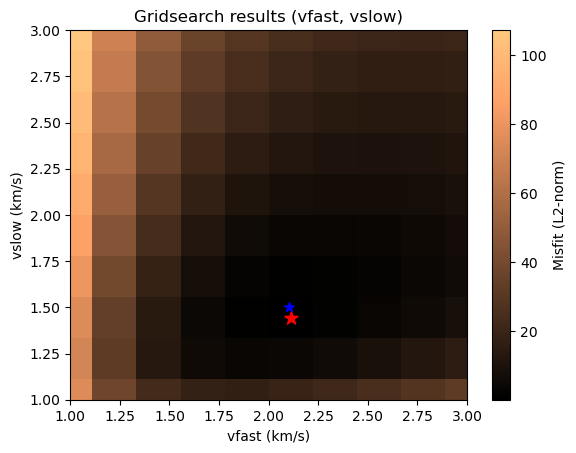

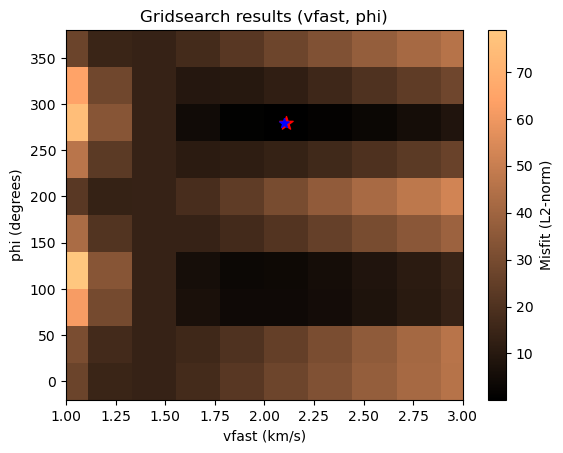

In [10]:
# Plot the result:
plt.figure()
Y, X = np.meshgrid(model_search_params[0,:], model_search_params[1,:])
plt.pcolormesh(X, Y, gridsearch_results[:,:,p3_idx[0]], cmap='copper')#, norm=matplotlib.colors.LogNorm(1e-1,1e4))
plt.colorbar(label='Misfit (L2-norm)')
plt.scatter(opt_model_params[0], opt_model_params[1], c='r', marker='*', s=100)
plt.scatter(vfast_synth, vslow_synth, c='b', marker='*', s=50)
plt.title('Gridsearch results (vfast, vslow)')
plt.xlim(1,3)
plt.ylim(1,3)
plt.xlabel('vfast (km/s)')
plt.ylabel('vslow (km/s)')
plt.show()

plt.figure()
Y, X = np.meshgrid(model_search_params[2,:], model_search_params[0,:])
plt.pcolormesh(X, Y, gridsearch_results[:,p2_idx[0],:], cmap='copper')#, norm=matplotlib.colors.LogNorm(1e-1,1e4))
plt.colorbar(label='Misfit (L2-norm)')
plt.scatter(opt_model_params[0], opt_model_params[2], c='r', marker='*', s=100)
plt.scatter(vfast_synth, fast_dir_deg, c='b', marker='*', s=50)
plt.title('Gridsearch results (vfast, phi)')
plt.xlim(1,3)
# plt.ylim(0,360)
plt.xlabel('vfast (km/s)')
plt.ylabel('phi (degrees)')
plt.show()

# # Find misfit:
# np.sum((d_obs - d_model)**2)
# # Good test - check that model equals data for zero noise.


## 4. Load in real data and perform preprocessing (cross-correlation):

In [ ]:
# Analyse real data:

# Specify parameters:
das_archive_dir = os.path.join("input_data", "das_data") 
ch_spacing_m = 1.6
pre_post_pad = [0.05, 0.15] # Note: this is important! A longer window gives more stable results...
max_tshift_idx = 100 


# And specify whether to calculate cc or use existing cc data:
calc_cc =  False #True


if calc_cc:
    # Loop through events:
    # And append event to dataframe:
    cc_data_df = pd.DataFrame({'event_uid': [], 'event_idx': [], 'rec1': [], 'rec2': [], 'dt': [], 'cc': [], 'nlloc_fname': []})
    count=0
    for event_idx in range(len(nlloc_hyp_filenames)):
        print( "Processing for event index: ", event_idx, "(", count+1, "/", len(nlloc_hyp_filenames), ")")
        # Read in nlloc event data:
        nlloc_hyp_data = NonLinLocPy.read_nonlinloc.read_hyp_file(nlloc_hyp_filenames[event_idx])
        event_uid = str(nlloc_hyp_data.origin_time).replace('-','').replace(':','').replace('T','').replace('Z','')

        trim_starttime = nlloc_hyp_data.origin_time - pre_post_pad[0] #obspy.UTCDateTime("2023-10-22T06:26:04.000000Z") 
        trim_endtime  = nlloc_hyp_data.origin_time + pre_post_pad[1] #obspy.UTCDateTime("2023-10-22T06:26:05.000000Z") 

        # Read in observed data:
        opt_archive_das_fname = find_das_archive_fname(das_archive_dir, nlloc_hyp_data.origin_time)
        st = obspy.read(opt_archive_das_fname, format="SEGY", starttime=trim_starttime-10, endtime=trim_endtime+10)
        st.filter('bandpass', freqmin=10, freqmax=500)
        st.trim(starttime=trim_starttime, endtime=trim_endtime)
        # And relabel receivers:
        for i in range(len(st)):
            st[i].stats.station = "D"+str(round(i*ch_spacing_m)).zfill(4)
            st[i].stats.channel = "HHZ"
            st[i].stats.distance = float(i*ch_spacing_m)
        fs = st[0].stats.sampling_rate

        # Calculate cross-correlation for each receiver pair:
        for i in range(receiver_corr_pairs.shape[0]):
            rec_1_idx = int(receiver_corr_pairs[i,0])
            rec_2_idx = int(receiver_corr_pairs[i,1])
            ncc = ncc_max_tshift(st.select(station=receivers_df.iloc[rec_1_idx].Name)[0].data, st.select(station=receivers_df.iloc[rec_2_idx].Name)[0].data, max_tshift_idx)
            dt_curr = (np.argmax(ncc) - max_tshift_idx) / fs # (in seconds)
            df_tmp = pd.DataFrame({'event_uid': [event_uid], 'event_idx': [count], 'rec1': [receivers_df.iloc[rec_1_idx].Name], 'rec1_idx': [rec_1_idx], 'rec2': [receivers_df.iloc[rec_2_idx].Name], 'rec2_idx': [rec_2_idx], 'dt': [dt_curr], 'cc': [np.max(ncc)], 'nlloc_fname': [nlloc_hyp_filenames[event_idx]]})
            cc_data_df = pd.concat([cc_data_df, df_tmp], ignore_index=True)

            if i % 10000 == 0:
                print("Calculating for receiver pair: ", i+1, "/", receiver_corr_pairs.shape[0])
        
        count+=1

    # Save data:
    cc_data_df.to_csv("gornergletscher_2023_surfwave_cc_data.csv", index=False)

    print("Finished calculating cross-correlation data for all events.")

else:   
    # Load in cc data:
    cc_data_df = pd.read_csv("gornergletscher_2023_surfwave_cc_data.csv")
    print("Loaded in data")
















Loaded in data


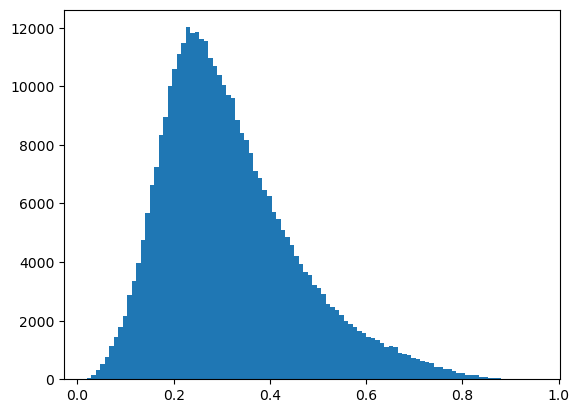

In [12]:
# Filter data by cc-value:
# (to reduce)

# Plot histogram of cc values (to determine appropriate threshold):
plt.figure()
plt.hist(cc_data_df['cc'].values, bins=100)
plt.show()

# Specify cc threshold:
cc_thresh = 0.7 #0.6 #0.5
cc_data_df = cc_data_df[cc_data_df['cc'] > cc_thresh]

/Users/tomhudson/anaconda3/envs/skience26_test/lib/python3.12/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (500) of bandpass is at or above Nyquist (500.0). Applying a high-pass instead.
  warnings.warn(msg)


event_uid                                  20231022091639.730469
event_idx                                                   13.0
rec1                                                       D0437
rec2                                                       D0766
dt                                                         0.001
cc                                                      0.745849
nlloc_fname    input_data/loc.Tom__RunNLLoc000.20231022.09163...
rec1_idx                                                    35.0
rec2_idx                                                   205.0
Name: 347801, dtype: object


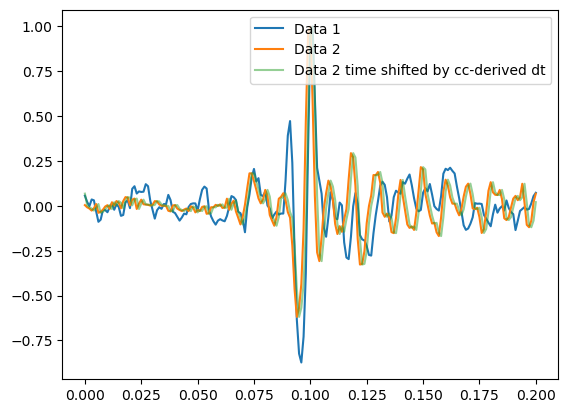

event_uid                                  20231022053231.527344
event_idx                                                    2.0
rec1                                                       D0416
rec2                                                       D0928
dt                                                        -0.015
cc                                                      0.725405
nlloc_fname    input_data/loc.Tom__RunNLLoc000.20231022.05323...
rec1_idx                                                    23.0
rec2_idx                                                   297.0
Name: 55944, dtype: object


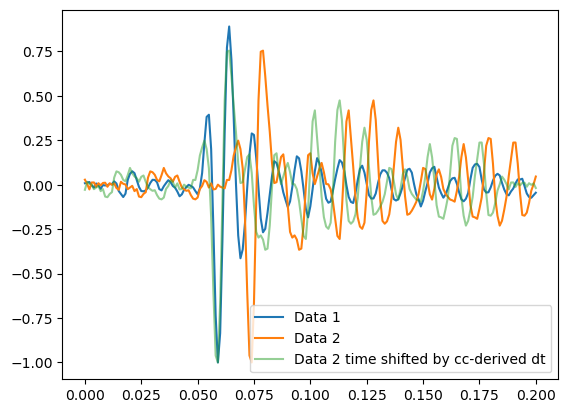

event_uid                                   20231022080438.71875
event_idx                                                   11.0
rec1                                                       D0856
rec2                                                       D0883
dt                                                         0.016
cc                                                      0.756937
nlloc_fname    input_data/loc.Tom__RunNLLoc000.20231022.08043...
rec1_idx                                                   259.0
rec2_idx                                                   271.0
Name: 315585, dtype: object


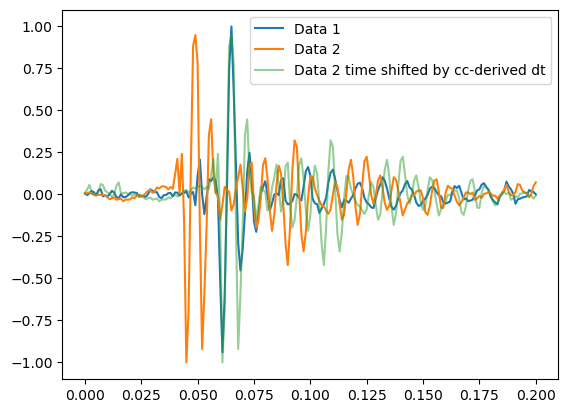

event_uid                                  20231022053231.527344
event_idx                                                    2.0
rec1                                                       D0411
rec2                                                       D0907
dt                                                        -0.019
cc                                                      0.775092
nlloc_fname    input_data/loc.Tom__RunNLLoc000.20231022.05323...
rec1_idx                                                    20.0
rec2_idx                                                   284.0
Name: 55567, dtype: object


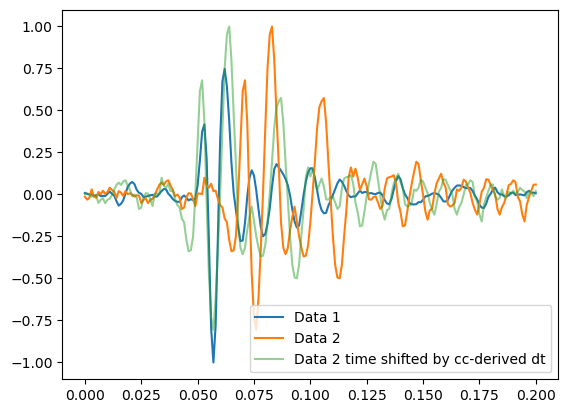

event_uid                                  20231022091639.730469
event_idx                                                   13.0
rec1                                                       D0603
rec2                                                       D0715
dt                                                        -0.033
cc                                                      0.710393
nlloc_fname    input_data/loc.Tom__RunNLLoc000.20231022.09163...
rec1_idx                                                   114.0
rec2_idx                                                   182.0
Name: 356937, dtype: object


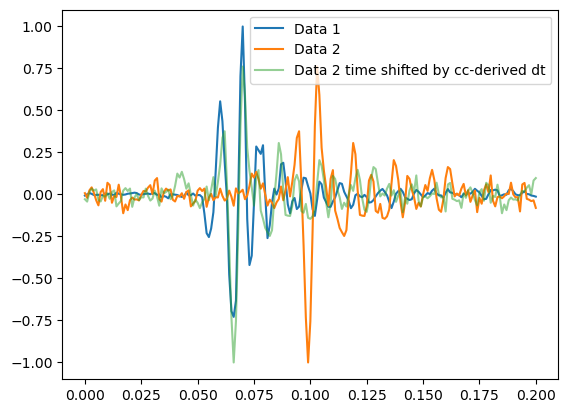

In [13]:
# Perform sanity check:

# Check random selection of data:

i_selection = np.random.randint(0, high=len(cc_data_df), size=5)

for i in i_selection:
    # Read in nlloc event data:
    nlloc_hyp_data = NonLinLocPy.read_nonlinloc.read_hyp_file(cc_data_df['nlloc_fname'].values[i])
    trim_starttime = nlloc_hyp_data.origin_time - pre_post_pad[0] #obspy.UTCDateTime("2023-10-22T06:26:04.000000Z") 
    trim_endtime  = nlloc_hyp_data.origin_time + pre_post_pad[1] #obspy.UTCDateTime("2023-10-22T06:26:05.000000Z") 
    # Read in observed data:
    opt_archive_das_fname = find_das_archive_fname(das_archive_dir, nlloc_hyp_data.origin_time)
    st = obspy.read(opt_archive_das_fname, format="SEGY", starttime=trim_starttime-10, endtime=trim_endtime+10)
    st.filter('bandpass', freqmin=10, freqmax=500)
    st.trim(starttime=trim_starttime, endtime=trim_endtime)
    # And relabel receivers:
    for ii in range(len(st)):
        st[ii].stats.station = "D"+str(round(ii*ch_spacing_m)).zfill(4)
        st[ii].stats.channel = "HHZ"
        st[ii].stats.distance = float(i*ch_spacing_m)
    fs = st[0].stats.sampling_rate



    print(cc_data_df.iloc[i])
    data_1 = st.select(station=cc_data_df['rec1'].values[i])[0].data
    data_2 = st.select(station=cc_data_df['rec2'].values[i])[0].data
    data_2_rolled = np.roll(data_2, int(cc_data_df['dt'].values[i]*fs))


    plt.figure()
    t = np.arange(0, len(data_1)) / fs
    plt.plot(t, data_1 / np.max(np.abs(data_1)), label='Data 1')
    plt.plot(t, data_2 / np.max(np.abs(data_2)), label='Data 2')
    plt.plot(t, data_2_rolled / np.max(np.abs(data_2_rolled)), alpha=0.5, label='Data 2 time shifted by cc-derived dt')
    plt.legend()
    plt.show()


## 5. Perform real data inversion:

In [14]:
# Perform real data inversion (test for 2 events):
# Construct the data:
d_obs = cc_data_df['dt'].values

#!!! REMOVE DC OFFSET FROM DATA !!!
# ??? IS THIS OK ???
# d_obs = d_obs - np.mean(d_obs)

# And the receiver pairs corresponding to the data:
receiver_corr_pairs_all_events = np.c_[cc_data_df['rec1_idx'].values, cc_data_df['rec2_idx'].values, cc_data_df['event_idx'].values] # Receiver 1 idx, receiver 2 idx, src/event idx

# And perform inversion:
gridsearch_results, model_search_params, src_rec_dists, src_rec_angles = peform_surf_tomo_gridsearch(receivers_df, sources_df, receiver_corr_pairs_all_events, d_obs, model_param_lims=np.array([[1,2.5],[1,2.5],[0,180]]), gridsearch_dims=40)

# Find optimal model:
(p1_idx, p2_idx, p3_idx) = np.where(gridsearch_results == np.min(gridsearch_results))
opt_model_params = [model_search_params[0,p1_idx[0]], model_search_params[1,p2_idx[0]], model_search_params[2,p3_idx[0]]]
print("Optimal model parameters: ", opt_model_params)
d_model_opt = forward_model(receiver_corr_pairs_all_events, src_rec_dists, src_rec_angles, opt_model_params[0], opt_model_params[1], opt_model_params[2])

Optimal model parameters:  [np.float64(1.7692307692307692), np.float64(1.5384615384615385), np.float64(4.615384615384615)]


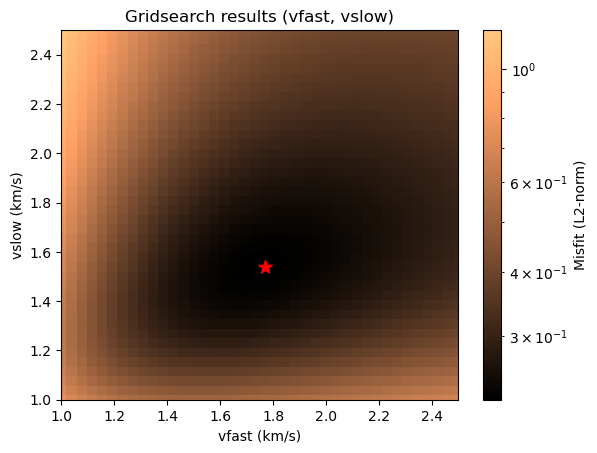

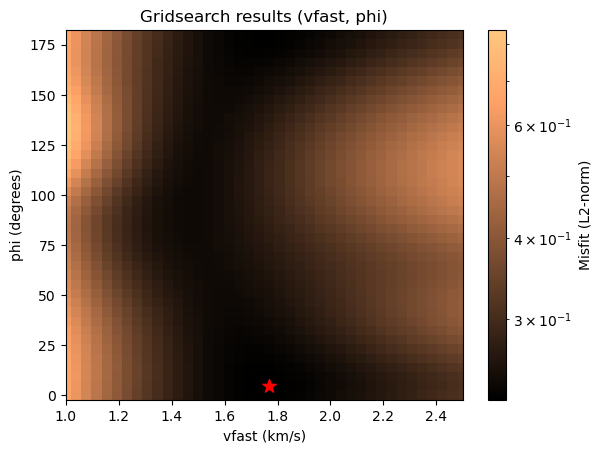

In [15]:
# And plot real data results:
plt.figure()
Y, X = np.meshgrid(model_search_params[1,:], model_search_params[0,:])
plt.pcolormesh(X, Y, gridsearch_results[:,:,p3_idx[0]], cmap='copper', norm=matplotlib.colors.LogNorm())
plt.colorbar(label='Misfit (L2-norm)')
plt.scatter(opt_model_params[0], opt_model_params[1], c='r', marker='*', s=100)
plt.title('Gridsearch results (vfast, vslow)')
plt.xlim(1,2.5)
plt.ylim(1,2.5)
plt.xlabel('vfast (km/s)')
plt.ylabel('vslow (km/s)')
plt.show()

plt.figure()
Y, X = np.meshgrid(model_search_params[2,:], model_search_params[0,:])
plt.pcolormesh(X, Y, gridsearch_results[:,p2_idx[0],:], cmap='copper', norm=matplotlib.colors.LogNorm())
plt.colorbar(label='Misfit (L2-norm)')
plt.scatter(opt_model_params[0], opt_model_params[2], c='r', marker='*', s=100)
plt.title('Gridsearch results (vfast, phi)')
plt.xlim(1,2.5)
# plt.ylim(0,360)
plt.xlabel('vfast (km/s)')
plt.ylabel('phi (degrees)')
plt.show()

# # Find misfit:
# np.sum((d_obs - d_model)**2)
# # Good test - check that model equals data for zero noise.


In [16]:
# Now update icequake locations with new model:
@jit(nopython=True, parallel=True)
def forward_model_location(receiver_corr_pairs, vfast, vslow, phi_deg, rec_xs, rec_ys, x0, y0):
    """Function to calculate the forward model for the location inversion.
    Returns the epicentral location for the given model parameters.
    Note: Indices of rec_xs and rec_ys correspond to the receiver pair indices in receiver_corr_pairs.
    dloc_model is the modelled differential arrival times for the given model parameters.
    """
    phi_rad = np.deg2rad(phi_deg)
    dloc_model = np.zeros(receiver_corr_pairs.shape[0])
    for jj in range(receiver_corr_pairs.shape[0]):
        rec_1_idx = int(receiver_corr_pairs[jj,0])
        rec_2_idx = int(receiver_corr_pairs[jj,1])
        src_idx = int(receiver_corr_pairs[jj,2])
        # (1 - 2):
        d1 = np.sqrt((rec_xs[rec_1_idx] - x0)**2 + (rec_ys[rec_1_idx] - y0)**2)
        d2 = np.sqrt((rec_xs[rec_2_idx] - x0)**2 + (rec_ys[rec_2_idx] - y0)**2)
        theta1 = np.arctan2(rec_xs[rec_1_idx] - x0, rec_ys[rec_1_idx] - y0) # back azimuth of receiver 1
        theta2 = np.arctan2(rec_xs[rec_2_idx] - x0, rec_ys[rec_2_idx] - y0) # back azimuth of receiver 2
        # Calculate differential arrival time between 1-2:
        dloc_model[jj] = (d1 / np.sqrt(vfast**2 * np.cos(theta1 - phi_rad)**2 + vslow**2 * np.sin(theta1 - phi_rad)**2)) - (d2 / np.sqrt(vfast**2 * np.cos(theta2 - phi_rad)**2 + vslow**2 * np.sin(theta2 - phi_rad)**2))
    return dloc_model


def peform_surf_loc_gridsearch(receivers_df, receiver_corr_pairs_all_events, d_obs, vfast, vslow, phi_deg, loc_model_param_lims=np.array([[-0.1, 0.1],[-0.1, 0.1]]), gridsearch_dims=200):
    """Perform surface wave location gridsearch for a single event, given the receiver geometry and the observed data.
    Note: This function assumes that the model parameters (vfast, vslow, phi) have already been found from the previous gridsearch, and are fixed for this location gridsearch.
    loc_model_param_lims: limits for the location model parameters (x0, y0) in km relative to the initial location."""

    # Specify receiver x and y arrays:
    rec_xs = receivers_df['x_m'].values
    rec_ys = receivers_df['y_m'].values
    
    # Perform gridsearch:
    # Define model param values to search over:
    loc_model_search_params = np.vstack((np.linspace(loc_model_param_lims[0,0], loc_model_param_lims[0,1], gridsearch_dims), np.linspace(loc_model_param_lims[1,0], loc_model_param_lims[1,1], gridsearch_dims)))
    loc_gridsearch_results = np.zeros((gridsearch_dims, gridsearch_dims))
    # And search over them:
    for i in range(loc_model_search_params.shape[1]):
        for j in range(loc_model_search_params.shape[1]):
                # Get current params:
                x0_curr = loc_model_search_params[0,i]
                y0_curr = loc_model_search_params[1,j]

                # Find all inter-event trace
                dloc_model = forward_model_location(receiver_corr_pairs_all_events, vfast, vslow, phi_deg, rec_xs, rec_ys, x0_curr, y0_curr)
                
                # And find misfit for current grid point:
                # (Based on L2-norm)
                loc_gridsearch_results[i,j] = np.sum((d_obs - dloc_model)**2)

    return loc_gridsearch_results, loc_model_search_params



Optimal location:  [np.float64(-0.016582914572864316), np.float64(-0.0407035175879397)]
Optimal location:  [np.float64(-0.060804020100502516), np.float64(-0.013567839195979897)]
Optimal location:  [np.float64(-0.1), np.float64(0.035678391959798994)]
Optimal location:  [np.float64(0.1), np.float64(-0.03969849246231156)]
Optimal location:  [np.float64(0.049748743718592975), np.float64(-0.1)]
Optimal location:  [np.float64(-0.08693467336683418), np.float64(0.019597989949748748)]
Optimal location:  [np.float64(-0.05979899497487437), np.float64(0.00954773869346734)]
Optimal location:  [np.float64(-0.025628140703517585), np.float64(0.00954773869346734)]
Optimal location:  [np.float64(-0.027638190954773864), np.float64(0.033668341708542715)]
Optimal location:  [np.float64(0.0015075376884422093), np.float64(0.02462311557788946)]
Optimal location:  [np.float64(-0.034673366834170855), np.float64(0.010552763819095479)]
Optimal location:  [np.float64(-0.029648241206030143), np.float64(0.0266331658

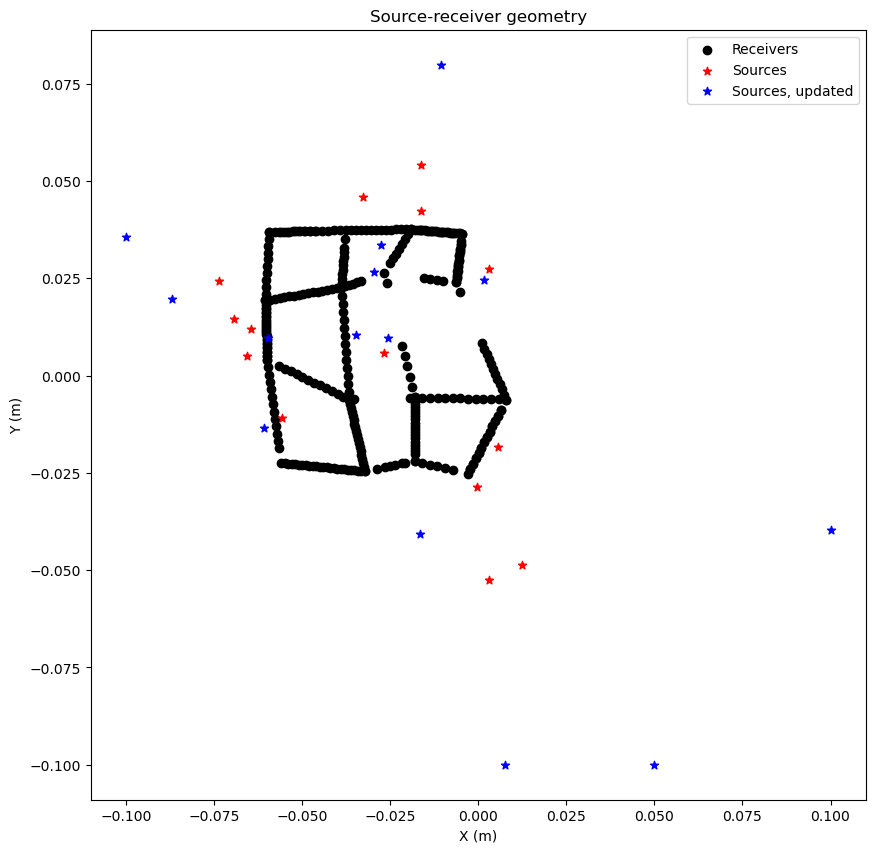

In [17]:
# Run location inversion:
vfast, vslow, phi_deg = opt_model_params
# Loop over events, solving for each:
receiver_corr_pairs_all_events = np.c_[cc_data_df['rec1_idx'].values, cc_data_df['rec2_idx'].values, cc_data_df['event_idx'].values]
event_idxs_for_loc = np.unique(receiver_corr_pairs_all_events[:,2])
event_updated_locs = np.zeros((len(event_idxs_for_loc), 2)) # x,y locations for each event
for event_idx in event_idxs_for_loc:
    curr_event_idx_set = np.where(receiver_corr_pairs_all_events[:,2] == event_idx)[0]
    receiver_corr_pairs_single_event = receiver_corr_pairs_all_events[curr_event_idx_set,:] #receiver_corr_pairs_all_events[receiver_corr_pairs_all_events[:,2] == event_idx]
    d_obs_single_event = d_obs[curr_event_idx_set]
    loc_gridsearch_results, loc_model_search_params = peform_surf_loc_gridsearch(receivers_df, receiver_corr_pairs_single_event, d_obs_single_event, vfast, vslow, phi_deg, loc_model_param_lims=np.array([[-0.1, 0.1],[-0.1, 0.1]]), gridsearch_dims=200)

    # Find optimal model:
    (loc_p1_idx, loc_p2_idx) = np.where(loc_gridsearch_results == np.min(loc_gridsearch_results))
    opt_loc_model_params = [loc_model_search_params[0,loc_p1_idx[0]], loc_model_search_params[1,loc_p2_idx[0]]]
    print("Optimal location: ", opt_loc_model_params)
    event_updated_locs[int(event_idx),0] = opt_loc_model_params[0] #x0
    event_updated_locs[int(event_idx),1] = opt_loc_model_params[1] #y0

# Update sources:
sources_df_updated = sources_df.copy()


# And plot up location results to check:
# Plot source-receiver geometry:
plt.figure(figsize=(10, 10))
plt.scatter(receivers_df['x_m'], receivers_df['y_m'], marker='o', color='k', label='Receivers')
plt.scatter(sources_df['x_m'], sources_df['y_m'], marker='*', color='r', label='Sources')
plt.scatter(event_updated_locs[:,0], event_updated_locs[:,1], marker='*', color='b', label='Sources, updated')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Source-receiver geometry')
plt.legend()
plt.show()

## 6. Perform iterative anisotropy-location inversion:

Iteration:  1 / 5
Optimal model parameters:  [np.float64(1.7692307692307692), np.float64(1.5384615384615385), np.float64(4.615384615384615)]
Optimal source locations:  [[-0.01708543 -0.03919598]
 [-0.05929648 -0.01306533]
 [-0.13366834  0.04723618]
 [ 0.2        -0.08542714]
 [ 0.06733668 -0.11959799]
 [-0.08542714  0.01909548]
 [-0.05929648  0.00904523]
 [-0.02512563  0.00904523]
 [-0.02713568  0.03517588]
 [ 0.00301508  0.02512563]
 [-0.03517588  0.01105528]
 [-0.02914573  0.02713568]
 [-0.01105528  0.07939698]
 [ 0.01306533 -0.11557789]]
Iteration:  2 / 5
Optimal model parameters:  [np.float64(1.7692307692307692), np.float64(1.5), np.float64(4.615384615384615)]
Optimal source locations:  [[-0.01708543 -0.04120603]
 [-0.05929648 -0.01306533]
 [-0.13366834  0.04924623]
 [ 0.2        -0.08542714]
 [ 0.06130653 -0.11758794]
 [-0.08140704  0.01909548]
 [-0.05929648  0.00904523]
 [-0.02512563  0.00904523]
 [-0.02713568  0.03517588]
 [ 0.00100503  0.02512563]
 [-0.03517588  0.01105528]
 [-

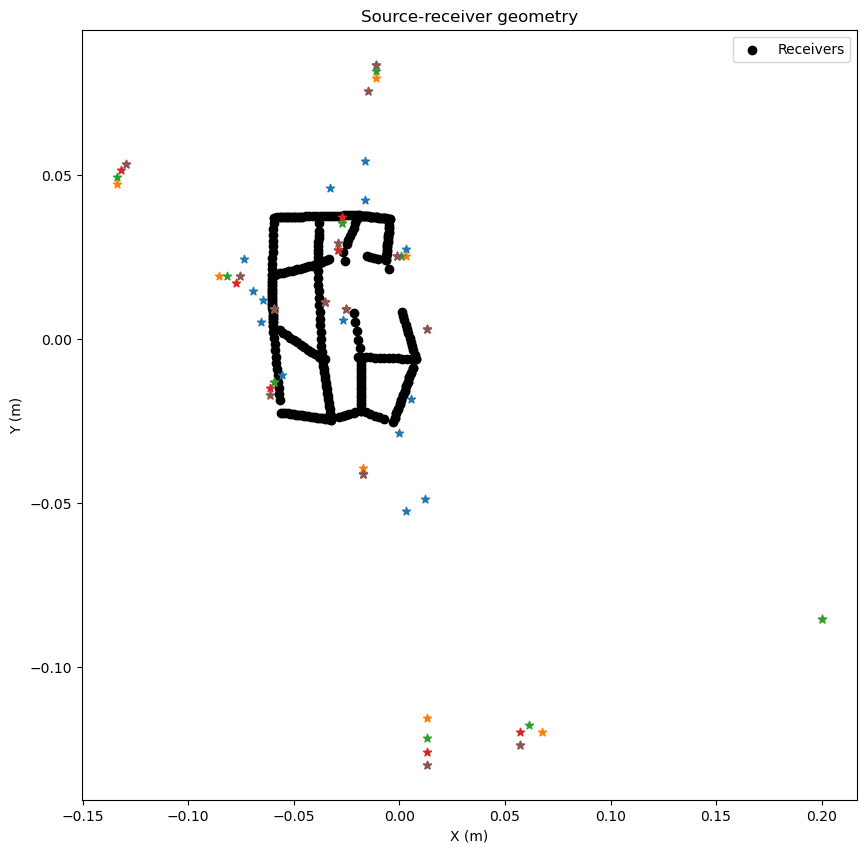

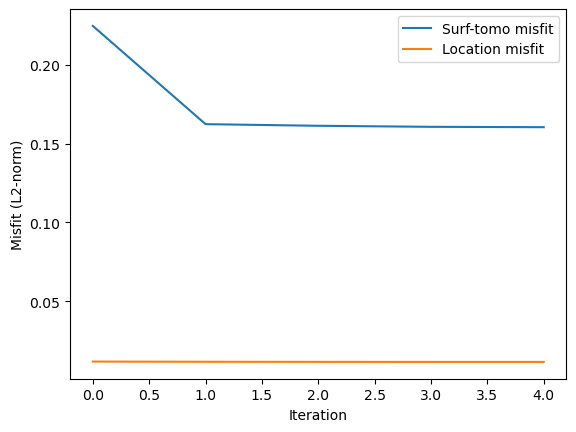

In [18]:
# Perform iterative surftomo-loc inversion:
n_iters = 5

# Setup plot to track icequake locations migration:
plt.figure(figsize=(10, 10))
plt.scatter(receivers_df['x_m'], receivers_df['y_m'], marker='o', color='k', label='Receivers')
plt.scatter(sources_df['x_m'], sources_df['y_m'], marker='*')

# Loop over iterations:
sources_df_updated = sources_df.copy()
surftomo_misfit = np.zeros(n_iters)
loc_misfit = np.zeros(n_iters)
for nn in np.arange(n_iters):
    print("Iteration: ", nn+1, "/", n_iters)
    # 1.i. Perform surf-tomo inversion:
    gridsearch_results, model_search_params, src_rec_dists, src_rec_angles = peform_surf_tomo_gridsearch(receivers_df, sources_df_updated, receiver_corr_pairs_all_events, d_obs, model_param_lims=np.array([[1,2.5],[1,2.5],[0,180]]), gridsearch_dims=40)
    
    # 1.ii. And find optimal velocity model:
    (p1_idx, p2_idx, p3_idx) = np.where(gridsearch_results == np.min(gridsearch_results))
    opt_model_params = [model_search_params[0,p1_idx[0]], model_search_params[1,p2_idx[0]], model_search_params[2,p3_idx[0]]]
    print("Optimal model parameters: ", opt_model_params)
    surftomo_misfit[nn] = np.min(gridsearch_results)

    # 2.i. Perform location inversion:
    # Loop over events, solving for each:
    vfast, vslow, phi_deg = opt_model_params
    # Loop over events, solving for each:
    receiver_corr_pairs_all_events = np.c_[cc_data_df['rec1_idx'].values, cc_data_df['rec2_idx'].values, cc_data_df['event_idx'].values]
    event_idxs_for_loc = np.unique(receiver_corr_pairs_all_events[:,2])
    event_updated_locs = np.zeros((len(event_idxs_for_loc), 2)) # x,y locations for each event
    loc_misfits_all_curr = []
    for event_idx in event_idxs_for_loc:
        curr_event_idx_set = np.where(receiver_corr_pairs_all_events[:,2] == event_idx)[0]
        receiver_corr_pairs_single_event = receiver_corr_pairs_all_events[curr_event_idx_set,:] #receiver_corr_pairs_all_events[receiver_corr_pairs_all_events[:,2] == event_idx]
        d_obs_single_event = d_obs[curr_event_idx_set]
        loc_gridsearch_results, loc_model_search_params = peform_surf_loc_gridsearch(receivers_df, receiver_corr_pairs_single_event, d_obs_single_event, vfast, vslow, phi_deg, loc_model_param_lims=np.array([[-0.2, 0.2],[-0.2, 0.2]]), gridsearch_dims=200)

        # Find optimal model:
        (loc_p1_idx, loc_p2_idx) = np.where(loc_gridsearch_results == np.min(loc_gridsearch_results))
        opt_loc_model_params = [loc_model_search_params[0,loc_p1_idx[0]], loc_model_search_params[1,loc_p2_idx[0]]]
        event_updated_locs[int(event_idx),0] = opt_loc_model_params[0] #x0
        event_updated_locs[int(event_idx),1] = opt_loc_model_params[1] #y0
        loc_misfits_all_curr.append(np.min(loc_gridsearch_results))

    

    # 2.ii. And update source locations:
    sources_df_updated['x_m'] = event_updated_locs[:,0]
    sources_df_updated['y_m'] = event_updated_locs[:,1]
    print("Optimal source locations: ", event_updated_locs)
    loc_misfit[nn] = np.mean(np.array(loc_misfits_all_curr))

    # 3.iii. Plot updated source locations:
    plt.scatter(sources_df_updated['x_m'], sources_df_updated['y_m'], marker='*')



# Finish tracking plot:
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Source-receiver geometry')
plt.legend()
plt.show()

# And plot misfit:
plt.figure()
plt.plot(surftomo_misfit, label='Surf-tomo misfit')
plt.plot(loc_misfit, label='Location misfit')
plt.xlabel('Iteration')
plt.ylabel('Misfit (L2-norm)')
plt.legend()
plt.show()


## 7. Vary number of events used and investigate effect on result

## 8. Explore other directions to take with the data...